In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Data/ST 4035 Customer Data.csv', index_col=0)
df.head()

,age,gender,race,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,DUIs,past_accidents,outcome
id,,,,,,,,,,,,,,,,,,
569520,65+,female,majority,0-9y,high school,upper class,0.629027,True,after 2015,False,True,10238,12000.0,sedan,0,0,0,False
750365,16-25,male,majority,0-9y,none,poverty,0.357757,False,before 2015,False,False,10238,16000.0,sedan,0,0,0,True
199901,16-25,female,majority,0-9y,high school,working class,0.493146,True,before 2015,False,False,10238,11000.0,sedan,0,0,0,False
478866,16-25,male,majority,0-9y,university,working class,0.206013,True,before 2015,False,True,32765,11000.0,sedan,0,0,0,False
731664,26-39,male,majority,10-19y,none,working class,0.388366,True,before 2015,False,False,32765,12000.0,sedan,2,0,1,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 569520 to 442696
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  object 
 1   gender               10000 non-null  object 
 2   race                 10000 non-null  object 
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  bool   
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  bool   
 10  children             10000 non-null  bool   
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  DUIs                 10000 non-null

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
credit_score,9018.0,0.515813,0.137688,0.053358,0.417191,0.525033,0.618312,0.960819
postal_code,10000.0,19864.548400,18915.613855,10238.000000,10238.000000,10238.000000,32765.000000,92101.000000
annual_mileage,9043.0,11697.003207,2818.434528,2000.000000,10000.000000,12000.000000,14000.000000,22000.000000
speeding_violations,10000.0,1.482900,2.241966,0.000000,0.000000,0.000000,2.000000,22.000000
DUIs,10000.0,0.239200,0.554990,0.000000,0.000000,0.000000,0.000000,6.000000
past_accidents,10000.0,1.056300,1.652454,0.000000,0.000000,0.000000,2.000000,15.000000


In [5]:
# Impute missing credit_score based on income
df['credit_score'] = df.groupby('income')['credit_score'].transform(lambda x: x.fillna(x.mean()))
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 569520 to 442696
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  object 
 1   gender               10000 non-null  object 
 2   race                 10000 non-null  object 
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         10000 non-null  float64
 7   vehicle_ownership    10000 non-null  bool   
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  bool   
 10  children             10000 non-null  bool   
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  DUIs                 10000 non-null

In [6]:
# Impute missing values in annual_mileage grouped by vehicle_year
df['annual_mileage'] = df.groupby('vehicle_year')['annual_mileage'].transform(lambda x: x.fillna(x.mean()))

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 569520 to 442696
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  object 
 1   gender               10000 non-null  object 
 2   race                 10000 non-null  object 
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         10000 non-null  float64
 7   vehicle_ownership    10000 non-null  bool   
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  bool   
 10  children             10000 non-null  bool   
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       10000 non-null  float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  DUIs                 10000 non-null

In [7]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# Converting numeric columns that might be loaded as strings
numeric_cols = df.select_dtypes(include=['object']).columns
for col in numeric_cols:
    # Attempt to convert to numeric, non-convertible values become NaN
    converted = pd.to_numeric(df[col], errors='coerce')
    # If at least 80% of the data is numeric, keep the conversion
    if converted.notna().sum() / len(df) > 0.8:
        df[col] = converted

# Converting boolean columns to integers (1 and 0)
# 1. Handle actual boolean datatypes
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns
for col in bool_cols:
    df[col] = df[col].astype(int)

# 2. Handle string representations of booleans (e.g., 'True', 'False', 'true', 'false')
for col in df.select_dtypes(include=['object']).columns:
    # Get unique, non-null values converted to lowercase strings
    unique_vals = set(df[col].dropna().astype(str).str.lower().unique())
    # If the column only contains true/false values, map them to 1/0
    if len(unique_vals) > 0 and unique_vals.issubset({'true', 'false'}):
        df[col] = df[col].astype(str).str.lower().map({'true': 1, 'false': 0})

# Converting categorical columns with low cardinality
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() / len(df) < 0.05:
        df[col] = df[col].astype('category')

# Display data types after conversion
print(df.dtypes)



age                    category
gender                 category
race                   category
driving_experience     category
education              category
income                 category
credit_score            float64
vehicle_ownership         int64
vehicle_year           category
married                   int64
children                  int64
postal_code               int64
annual_mileage          float64
vehicle_type           category
speeding_violations       int64
DUIs                      int64
past_accidents            int64
outcome                   int64
dtype: object


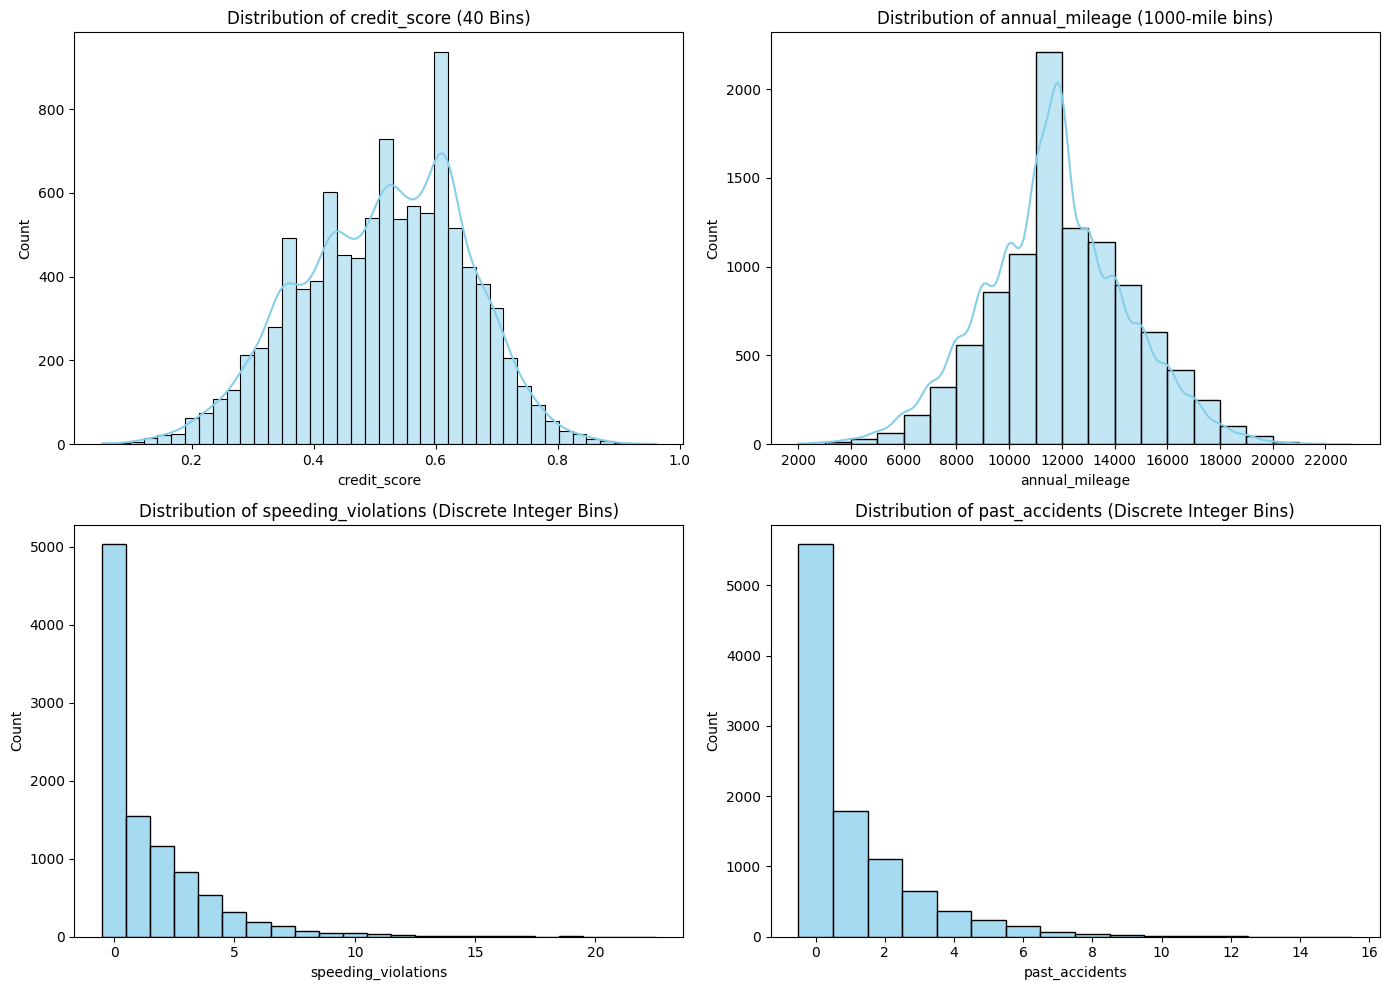

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Credit Score number of bins
sns.histplot(df['credit_score'], bins=40, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of credit_score (40 Bins)', fontsize=12)

# Annual Mileage bin
sns.histplot(df['annual_mileage'], bins=range(2000, 24000, 1000), kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of annual_mileage (1000-mile bins)', fontsize=12)
axes[0, 1].set_xticks(range(2000, 24000, 2000))

#Speeding Violations
sns.histplot(df['speeding_violations'], discrete=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Distribution of speeding_violations (Discrete Integer Bins)', fontsize=12)

#Past Accidents
sns.histplot(df['past_accidents'], discrete=True, ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Distribution of past_accidents (Discrete Integer Bins)', fontsize=12)

plt.tight_layout()

#### Most of customers have a average credit score.
#### There is spike at the number zero in speeding violations and past accidents. This tells us that the majority of people in this dataset have a perfectly clean driving record.
#### Anual milage plot shows that most people are average drivers who travel between 10,000 and 13,000 miles a year. Very few drivers travel less than 6000 and very few drive extreme distances.

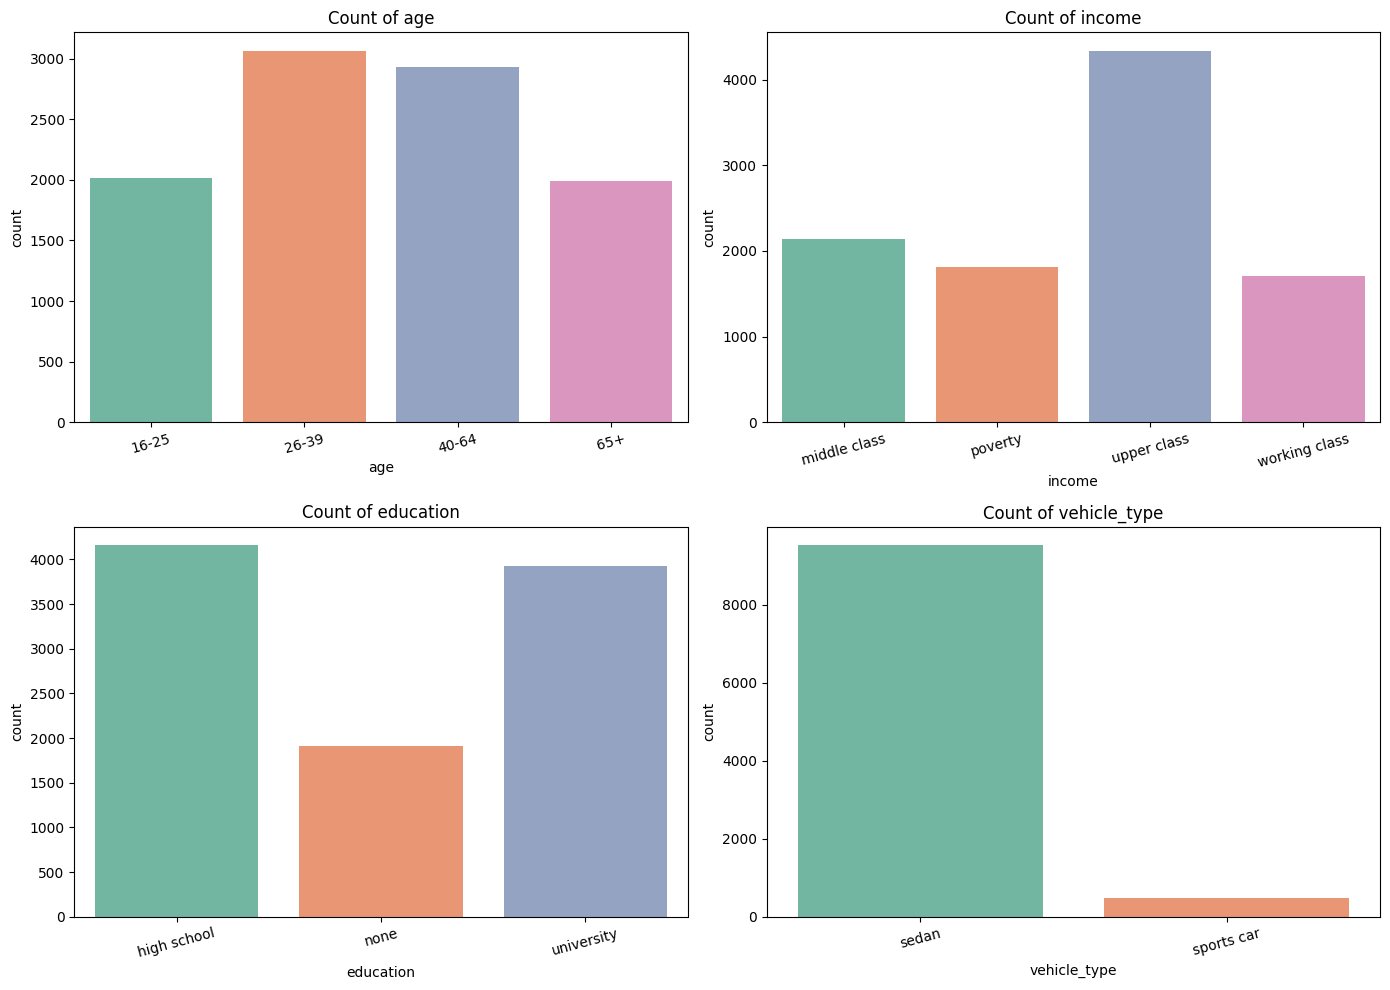

In [9]:
categorical_features = ['age', 'income', 'education', 'vehicle_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i//2, i%2], palette='Set2', hue=col)
    axes[i//2, i%2].set_title(f'Count of {col}', fontsize=12)
    axes[i//2, i%2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

#### The biggest groups of customers are adults between the ages of 26 and 64. We have fewer young drivers (16-25) and senior citizens (65+).
#### The majority of the customers are upper class and similar amount of customers are from working class and poverty.
#### Almost every customer is driving a sedan while very few customers driving sports cars.

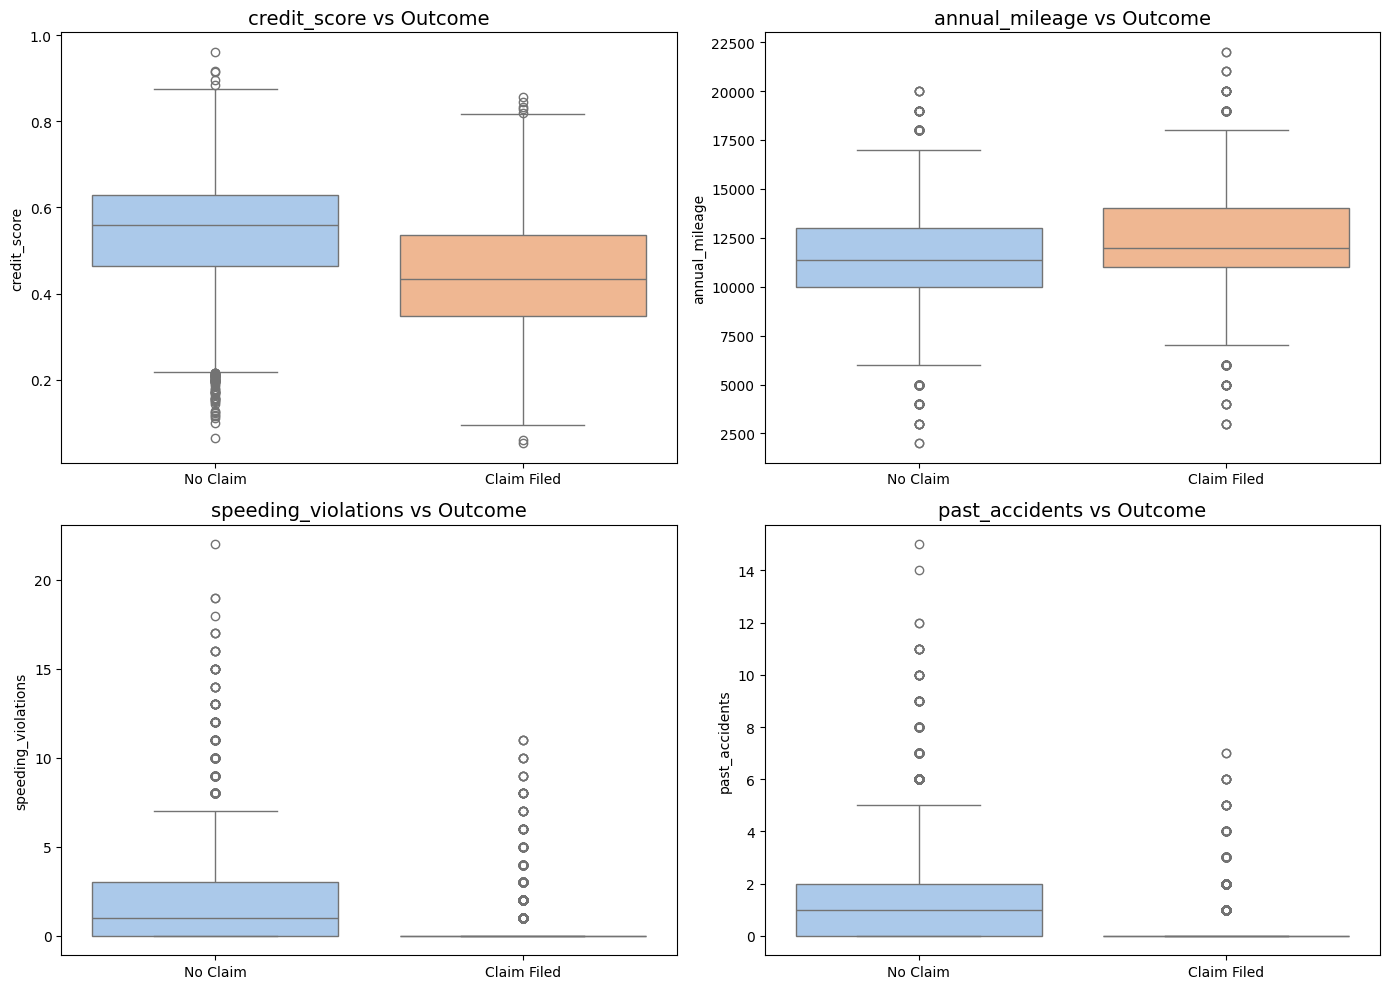

In [10]:
# --- Bivariate Analysis ---

df['Outcome_Label'] = df['outcome'].map({0: 'No Claim', 1: 'Claim Filed'})

# Numerical Features vs Outcome (Boxplots)
numerical_features = ['credit_score', 'annual_mileage', 'speeding_violations', 'past_accidents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(numerical_features):
    # Using boxplots to easily compare medians and see outliers
    sns.boxplot(data=df, x='Outcome_Label', y=col, ax=axes[i//2, i%2], palette='pastel', hue='Outcome_Label')
    axes[i//2, i%2].set_title(f'{col} vs Outcome', fontsize=14)
    axes[i//2, i%2].set_xlabel('')
    axes[i//2, i%2].set_ylabel(col)
plt.tight_layout()
plt.show()

In [11]:
made_claim = df['outcome'].isin([1, True, 'True', 'true'])

claim_and_speeding = df[made_claim & (df['speeding_violations'] > 0)]
count_speeding = len(claim_and_speeding)

claim_and_accidents = df[made_claim & (df['past_accidents'] > 0)]
count_accidents = len(claim_and_accidents)

print(f"Total people who made a claim AND have a speeding violation: {count_speeding}")
print(f"Total people who made a claim AND have a past accident: {count_accidents}")

Total people who made a claim AND have a speeding violation: 661
Total people who made a claim AND have a past accident: 510


#### When observing Past Accidents & Speeding Violations people with no speeding violations and people with no past accidents have made claims compared to people with accidents and speeding violations.

#### Customers with lower median credit score and higher median anual milage has made more claims comared to others

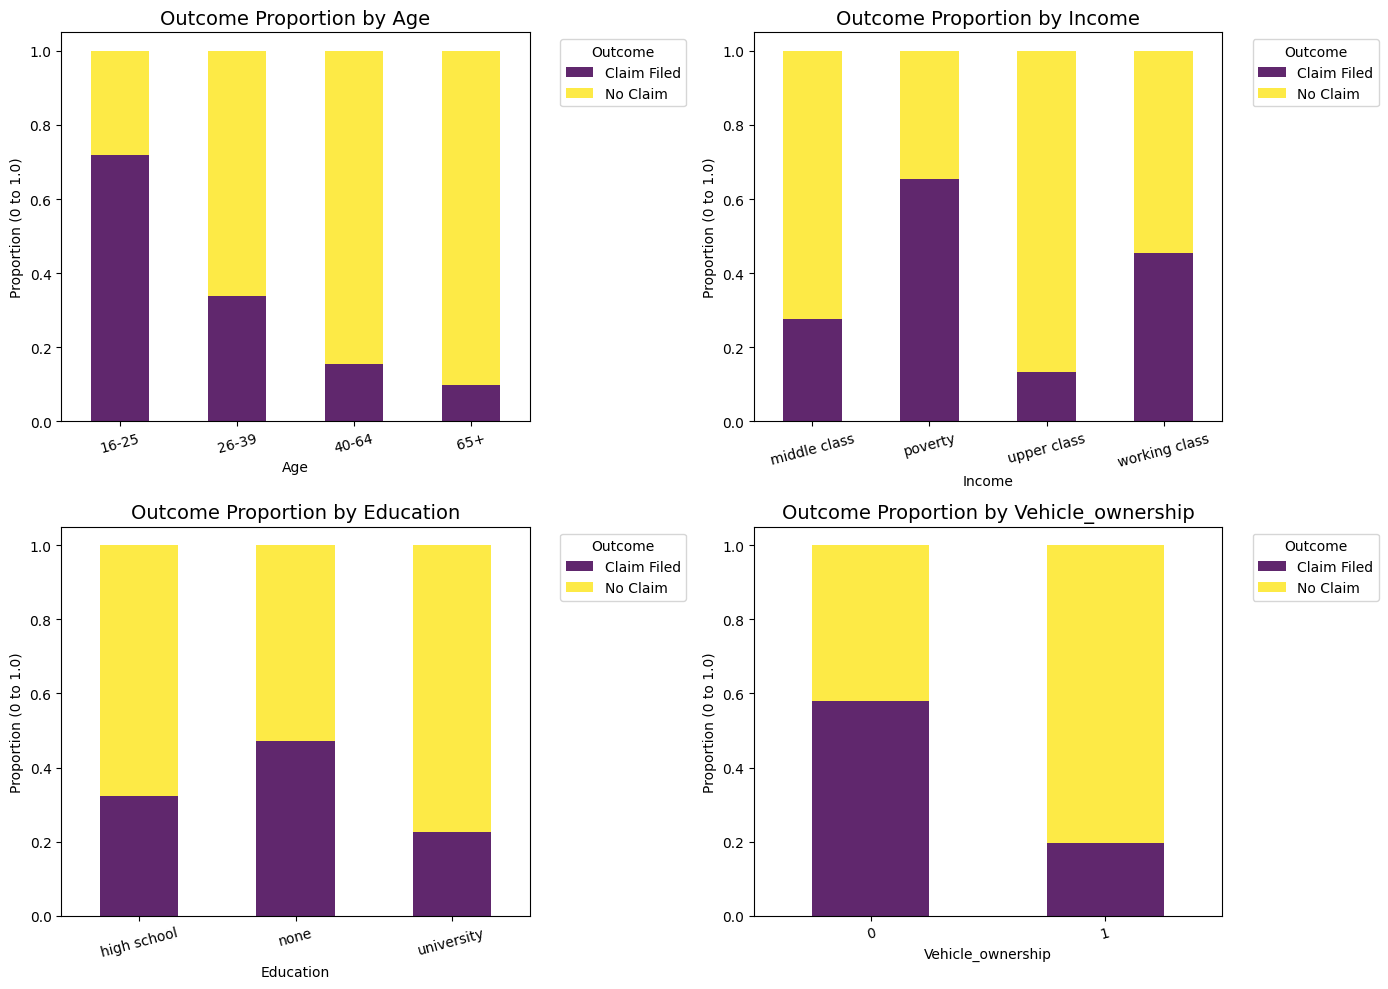

In [12]:
# Categorical Features vs Outcome (Stacked Proportion Bars)
categorical_features = ['age', 'income', 'education', 'vehicle_ownership']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(categorical_features):
    # Calculate proportions (normalize='index' makes each bar equal 100%)
    crosstab = pd.crosstab(df[col], df['Outcome_Label'], normalize='index')
    
    # Plot the stacked bar chart
    crosstab.plot(kind='bar', stacked=True, ax=axes[i//2, i%2], colormap='viridis', alpha=0.85)
    
    axes[i//2, i%2].set_title(f'Outcome Proportion by {col.capitalize()}', fontsize=14)
    axes[i//2, i%2].set_ylabel('Proportion (0 to 1.0)')
    axes[i//2, i%2].set_xlabel(col.capitalize())
    axes[i//2, i%2].tick_params(axis='x', rotation=15)
    
    # Clean up the legend so it doesn't overlap the bars
    axes[i//2, i%2].legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

df.drop('Outcome_Label', axis=1, inplace=True)

#### Majority proportion of customers in the age group between 16-25 has made claims, which is around 70% . Also majority proportion of customers in poverty group has made claims compared to rest of the income grops.

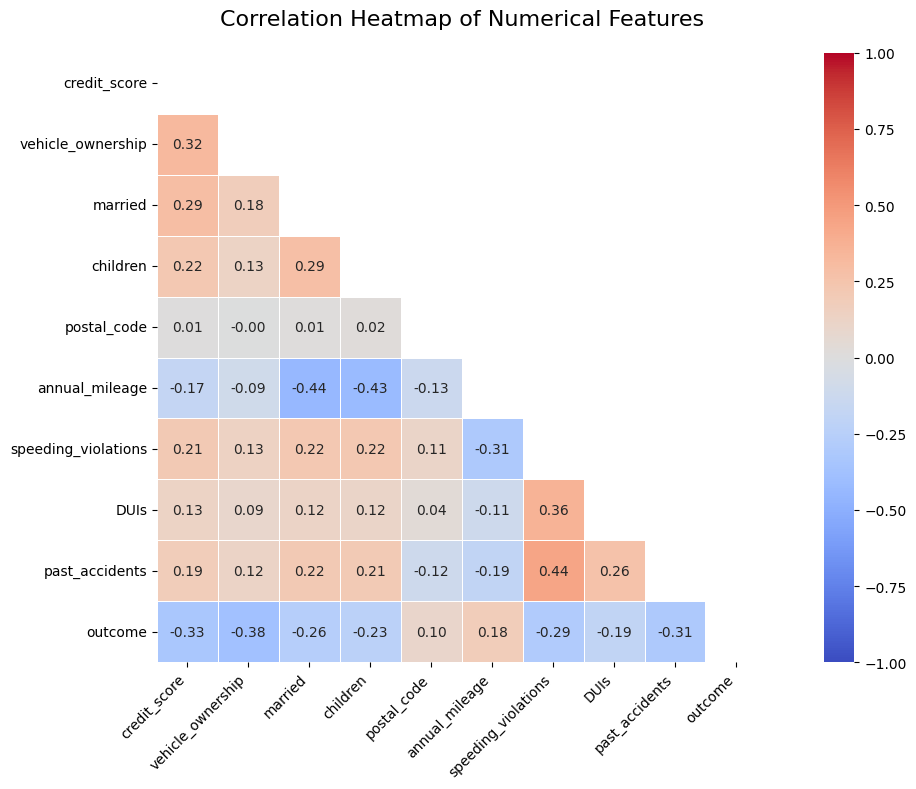

In [13]:
# --- Multivariate Analysis ---

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar=True, square=True, linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### The strongest negative connections to filing a claim are Vehicle Ownership (-0.38) and Credit Score (-0.33).
#### If a customer actually owns the car they are driving and has a high credit score, their chances of filing a claim drop significantly.
#### strong negative connection between filing a claim and Past Accidents (-0.31) and Speeding Violations (-0.29).
#### As the number of old accidents and speeding tickets goes up, the likelihood of filing a claim today goes down.This shows that having a messy past is actually a sign of experience, making them safer than someone with a perfectly blank record.